# Monte Carlo methods

Following **Chapter 5** from *Reinforcement Learning* (edition 2) by Andrew Barto and Richard S. Sutton

### Setup

In [40]:
import numpy as np
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
from typing import Callable

### Blackjack

In [52]:
def draw_card():
    # Cards are 1 (Ace) through 10, with J/Q/K counted as 10
    return np.random.randint(1, 11)


def add_card(total: int, usable_ace: bool, card: int):
    """
    Update hand total and usable ace status after drawing a card.
    """
    if card == 1:  # Ace
        if total + 11 <= 21:
            total += 11
            usable_ace = True
        else:
            total += 1
    else:
        total += card

    # Convert usable ace from 11 -> 1 if bust
    if total > 21 and usable_ace:
        total -= 10
        usable_ace = False

    return total, usable_ace


def run_episode(pi_s: Callable) -> tuple[list, list, int]:
    states, actions = [], []

    # ----- Dealer initial hand -----
    dealer_showing = draw_card()
    dealer_hidden = draw_card()

    dealer_sum = 0
    dealer_usable_ace = False
    dealer_sum, dealer_usable_ace = add_card(
        dealer_sum, dealer_usable_ace, dealer_showing
    )
    dealer_sum, dealer_usable_ace = add_card(
        dealer_sum, dealer_usable_ace, dealer_hidden
    )

    # ----- Player initial hand -----
    player_sum = 0
    usable_ace = False
    player_sum, usable_ace = add_card(
        player_sum, usable_ace, draw_card()
    )
    player_sum, usable_ace = add_card(
        player_sum, usable_ace, draw_card()
    )

    s = (player_sum, dealer_showing, usable_ace)

    # Natural blackjack
    if player_sum == 21:
        if dealer_sum == 21:
            return [s], [0], 0
        return [s], [0], 1

    # ----- Player turn -----
    while True:
        s = (player_sum, dealer_showing, usable_ace)
        a = pi_s(s)  # 1 = hit, 0 = stick
        states.append(s)
        actions.append(a)

        if a == 1:  # hit
            card = draw_card()
            player_sum, usable_ace = add_card(
                player_sum, usable_ace, card
            )

            if player_sum > 21:
                return states, actions, -1 # player bust

        else:  # stick
            break

    # ----- Dealer turn -----
    while dealer_sum < 17: # Dealer fixed policy
        card = draw_card()
        dealer_sum, dealer_usable_ace = add_card(
            dealer_sum, dealer_usable_ace, card
        )

    # ----- Determine outcome -----
    if dealer_sum > 21:
        _return = 1 # dealer bust, player win
    elif player_sum > dealer_sum:
        _return = 1 # player win
    elif player_sum < dealer_sum:
        _return = -1 # dealer win
    else:
        _return = 0 # draw

    return states, actions, _return

def initialize_V_pi():
    V_pi = {}
    for usable_ace in [True, False]:
        for dealer_showing in list(range(1, 11)): # Dealer can show between 1-10
            for player_sum in list(range(12, 22)): # Player automatically hits under 12
                s = (player_sum, dealer_showing, usable_ace)
                V_pi[s] = 0
    return V_pi

def initialize_returns():
    returns = {}
    for usable_ace in [True, False]:
        for dealer_showing in list(range(1, 11)): # Dealer can show between 1-10
            for player_sum in list(range(12, 22)): # Player automatically hits under 12
                s = (player_sum, dealer_showing, usable_ace)
                returns[s] = []
    return returns

def plot_value_function(V_pi):
    """
    V_pi: dict mapping
        (player_sum, dealer_showing, usable_ace) -> value
    """

    dealer_showing = np.arange(1, 11)
    player_sum = np.arange(12, 22)

    X, Y = np.meshgrid(dealer_showing, player_sum)

    fig = plt.figure(figsize=(14, 6))

    for i, usable_ace in enumerate([True, False]):

        Z = np.zeros_like(X, dtype=float)

        for row, p_sum in enumerate(player_sum):
            for col, d_show in enumerate(dealer_showing):
                Z[row, col] = V_pi.get(
                    (p_sum, d_show, usable_ace),
                    0.0
                )

        ax = fig.add_subplot(1, 2, i + 1, projection="3d")

        ax.plot_surface(
            X,
            Y,
            Z,
            rstride=1,
            cstride=1,
            cmap="viridis",
            edgecolor="none"
        )

        ax.set_xlabel("Dealer Showing")
        ax.set_ylabel("Player Sum")
        ax.set_zlabel("Value")

        ax.set_xticks(np.arange(1, 11))
        ax.set_yticks(np.arange(12, 22))

        ax.set_title(
            "Usable Ace" if usable_ace else "No Usable Ace"
        )

        ax.view_init(elev=25, azim=-135)

    plt.tight_layout()
    plt.show()

In [53]:
naive_deterministic_policy = lambda s:  0 if s[0] >= 20 else 1 # stick if 20 or 21, else hit
run_episode(naive_deterministic_policy)

([(10, 1, False), (12, 1, False), (20, 1, False)], [1, 1, 0], 1)

### Blackjack MC policy evaluation (prediction)

Page *92*. Reward calculation is skipped, as return is given directly per episode. No first-visit check required, as no states can be revisited in blackjack.

Episode: 100%|██████████| 1000000/1000000 [13:00<00:00, 1280.64it/s]


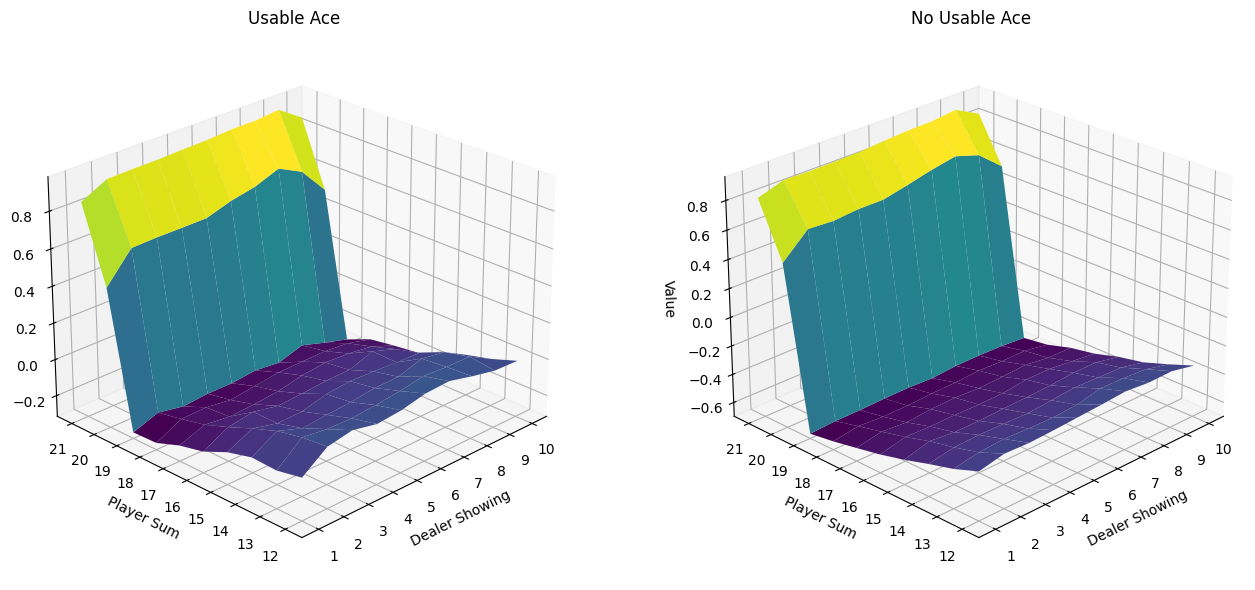

In [57]:
num_episodes = 1000000
V_pi = initialize_V_pi()
returns = initialize_returns()

for i in tqdm(range(num_episodes), desc="Episode"):
    states, actions, _return = run_episode(pi_s=naive_deterministic_policy)
    for t in reversed(range(len(states))):
        s_t = states[t]
        if s_t not in V_pi.keys():
            continue
        returns[s_t].append(_return)
        V_pi[s_t] = np.mean(returns[s_t])

plot_value_function(V_pi)